# Homework 4: Sequence Models & Word Embeddings
## Projects in Machine Learning and AI — RPI Spring 2026

---

This notebook covers:
- **Task 2** (50 pts): RNN, LSTM, GRU on a time-series dataset
- **Task 3** (50 pts): Word Embeddings, Cosine Similarity, and a Novel Dissimilarity Metric


---
# Task 2: Sequence Models on Time-Series Data (50 points)

## Dataset: Daily Climate Time Series

**Dataset Source:** [DailyDelhiClimateTrain — Kaggle](https://www.kaggle.com/datasets/ciochdawid/dailydelhiclimatetrain-csv/data)

**Problem Statement:** Predict the next day's mean temperature given a sliding window of past daily observations (mean temp, humidity, wind speed, mean pressure).

**Why Sequence Models?**  
Climate data is inherently temporal — today's temperature depends heavily on yesterday's and the days before. A standard feed-forward network treats each input sample independently and loses this temporal dependency. Sequence models (RNN, LSTM, GRU) maintain a hidden state across time steps, allowing them to capture temporal patterns, seasonal cycles, and trends that are critical for accurate forecasting. Without modelling the sequential order, predictive accuracy would drop significantly.


In [1]:
# ── Install
!pip install -q numpy pandas matplotlib scikit-learn torch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## Data Loading & Pre-processing

In [10]:
# ── Load the real Kaggle dataset ────────────────────────────────────────────
# Place DailyDelhiClimateTrain.csv in the same folder as this notebook,
# or update the path below.
import os
import pandas as pd

# import kagglehub
# # Download latest version
# path = kagglehub.dataset_download("ciochdawid/dailydelhiclimatetrain-csv")
# print("Path to dataset files:", path)
# path = "/root/.cache/kagglehub/datasets/ciochdawid/dailydelhiclimatetrain-csv/versions/1/DailyDelhiClimateTrain.csv"
# df = pd.read_csv(path)

CSV_PATH = '/root/.cache/kagglehub/datasets/ciochdawid/dailydelhiclimatetrain-csv/versions/1/DailyDelhiClimateTrain.csv'

df = pd.read_csv(CSV_PATH, parse_dates=['date'])
df.set_index('date', inplace=True)
# Normalise column names
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
EXPECTED = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
rename_map = {}
for col in df.columns:
    for exp in EXPECTED:
        if exp.replace('_','') in col.replace('_',''):
            rename_map[col] = exp
df.rename(columns=rename_map, inplace=True)
df = df[EXPECTED]
print(f'Loaded real dataset: {df.shape}')


print(df.shape)
df.head()

Loaded real dataset: (1462, 4)
(1462, 4)


,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


### Exploratory Data Visualization

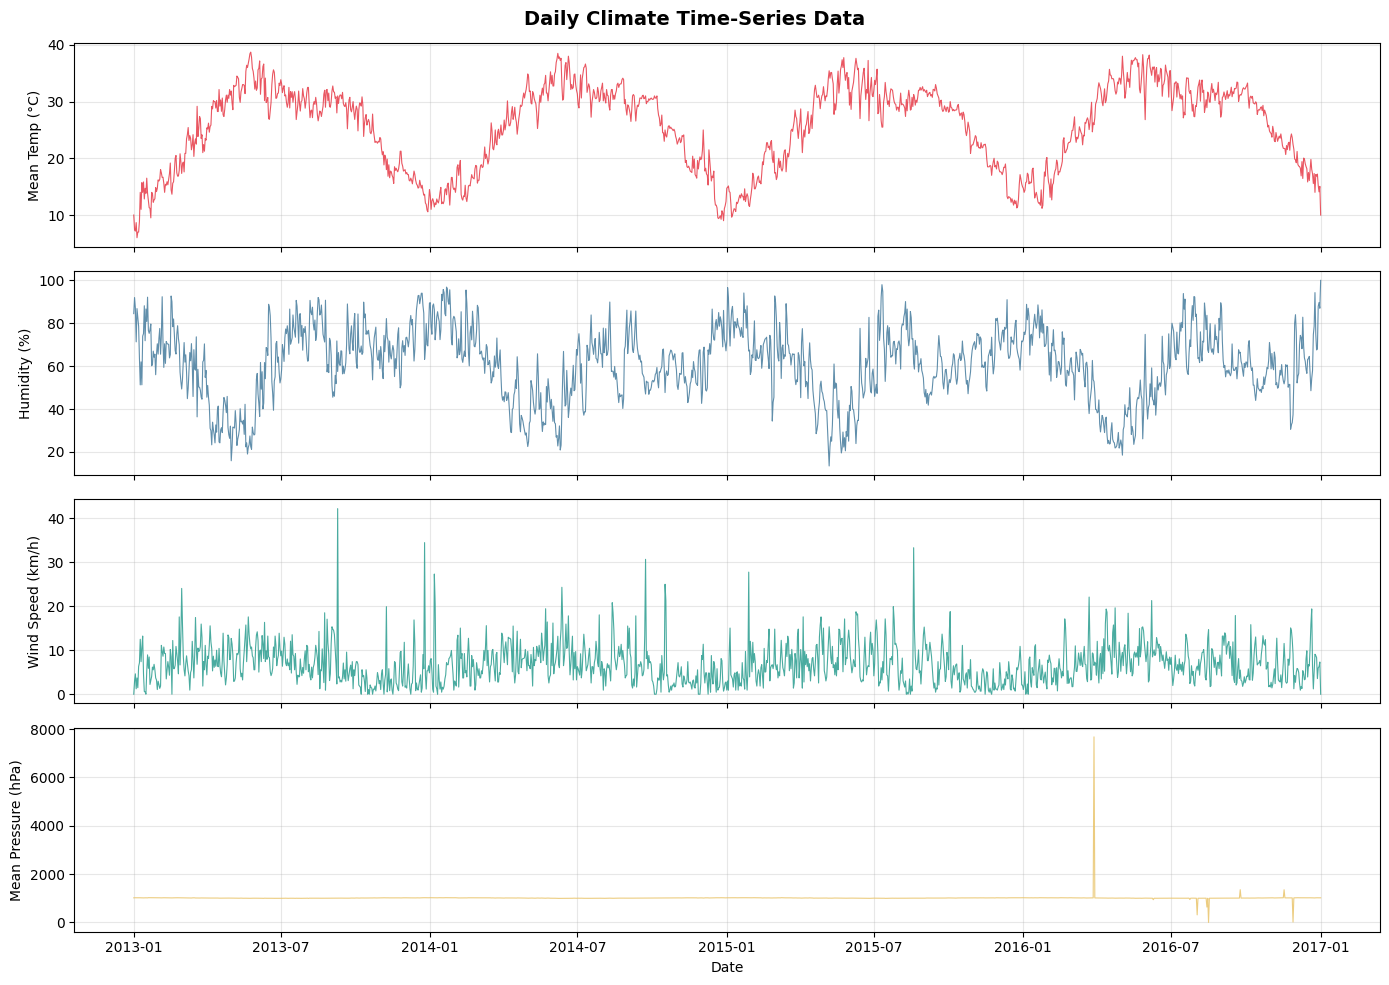

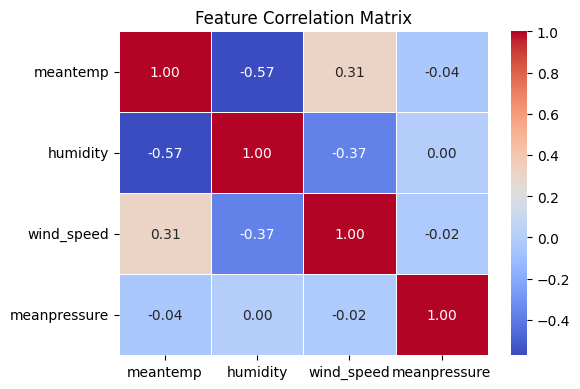

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
cols   = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
colors = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']
labels = ['Mean Temp (°C)', 'Humidity (%)', 'Wind Speed (km/h)', 'Mean Pressure (hPa)']

for ax, col, color, label in zip(axes, cols, colors, labels):
    ax.plot(df.index, df[col], color=color, linewidth=0.8, alpha=0.85)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Daily Climate Time-Series Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [12]:
# ── Check for missing values ────────────────────────────────────────────────
print('Missing values per column:')
print(df.isnull().sum())
print('\nBasic statistics:')
df.describe()

Missing values per column:
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Basic statistics:


,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


In [15]:
# Normalisation (MinMax → [0, 1])
FEATURES = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
TARGET   = 'meantemp'

scaler   = MinMaxScaler()
scaled   = scaler.fit_transform(df[FEATURES].values)   # shape (n, 4)
target_scaler = MinMaxScaler()
target_scaled = target_scaler.fit_transform(df[[TARGET]].values)  # shape (n, 1)

# Sliding-window dataset
SEQ_LEN = 30  # use 30 past days to predict day 31

def create_sequences(features, target, seq_len):
    X, y = [], []
    for i in range(len(features) - seq_len):
        X.append(features[i:i+seq_len])
        y.append(target[i+seq_len])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, target_scaled.squeeze(), SEQ_LEN)
print(f'X shape: {X.shape}, y shape: {y.shape}')

# Train / Val / Test split: 70 / 15 / 15
n_total = len(X)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)

X_train, y_train = X[:n_train],          y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],    y[n_train+n_val:]

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

X shape: (1432, 30, 4), y shape: (1432,)
Train: 1002, Val: 214, Test: 216


In [16]:
# PyTorch Dataset & DataLoader
class ClimateDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH = 64
train_loader = DataLoader(ClimateDataset(X_train, y_train), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(ClimateDataset(X_val,   y_val),   batch_size=BATCH)
test_loader  = DataLoader(ClimateDataset(X_test,  y_test),  batch_size=BATCH)

---
## Part 1 — Basic RNN (10 points)

**Architecture:**
- 1 vanilla RNN layer (hidden size = 64, tanh activation at each time step)
- Dropout (0.2) after the RNN layer
- 1 fully-connected output layer (Linear → scalar)
- **Output activation:** None (regression; raw linear output)

**Performance Metric:** Root Mean Squared Error (RMSE) — measured on both **validation** and **test** sets. RMSE penalises large errors more heavily, which is important for temperature forecasting.

In [18]:
#  Generic training / evaluation helpers
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    """Train a model; return per-epoch train/val loss lists."""
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        # -- train
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_losses.append(loss.item())
        train_losses.append(np.mean(batch_losses))

        # validate
        model.eval()
        vlosses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                vlosses.append(criterion(model(xb), yb).item())
        val_losses.append(np.mean(vlosses))

        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d}/{epochs}  Train MSE: {train_losses[-1]:.5f}  Val MSE: {val_losses[-1]:.5f}')

    return train_losses, val_losses


def evaluate_model(model, loader, scaler):
    """Return predictions and targets in original scale, plus RMSE and MAE."""
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            preds.append(model(xb).cpu().numpy())
            targets.append(yb.numpy())
    preds   = np.concatenate(preds).squeeze()
    targets = np.concatenate(targets).squeeze()
    # inverse-scale
    preds_orig   = scaler.inverse_transform(preds.reshape(-1,1)).squeeze()
    targets_orig = scaler.inverse_transform(targets.reshape(-1,1)).squeeze()
    rmse = np.sqrt(mean_squared_error(targets_orig, preds_orig))
    mae  = mean_absolute_error(targets_orig, preds_orig)
    return preds_orig, targets_orig, rmse, mae


def plot_loss(train_losses, val_losses, title):
    plt.figure(figsize=(9, 4))
    plt.plot(train_losses, label='Train Loss (MSE)', color='#264653')
    plt.plot(val_losses,   label='Val Loss (MSE)',   color='#e76f51')
    plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
    plt.title(title); plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_predictions(targets, preds, title):
    plt.figure(figsize=(12, 4))
    plt.plot(targets, label='Actual',    color='#264653', linewidth=1)
    plt.plot(preds,   label='Predicted', color='#e76f51', linewidth=1, alpha=0.8)
    plt.xlabel('Days'); plt.ylabel('Mean Temp (°C)')
    plt.title(title); plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

In [19]:
#  Basic RNN Model
class BasicRNN(nn.Module):
    """
    Structure:
      - nn.RNN with tanh activation (PyTorch default) at each time step
      - Dropout(0.2)
      - Linear(64 → 1) output layer  [no activation → raw regression]
    """
    def __init__(self, input_size=4, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                          batch_first=True, nonlinearity='tanh')
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)         # out: (batch, seq, hidden)
        out = self.drop(out[:, -1])  # take last time step
        return self.fc(out)


rnn_model = BasicRNN()
print(rnn_model)
print(f'\nTotal parameters: {sum(p.numel() for p in rnn_model.parameters()):,}')

BasicRNN(
  (rnn): RNN(4, 64, batch_first=True)
  (drop): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 4,545


=== Training Basic RNN ===
Epoch  10/50  Train MSE: 0.00687  Val MSE: 0.00484
Epoch  20/50  Train MSE: 0.00543  Val MSE: 0.00438
Epoch  30/50  Train MSE: 0.00455  Val MSE: 0.00401
Epoch  40/50  Train MSE: 0.00465  Val MSE: 0.00362
Epoch  50/50  Train MSE: 0.00399  Val MSE: 0.00344


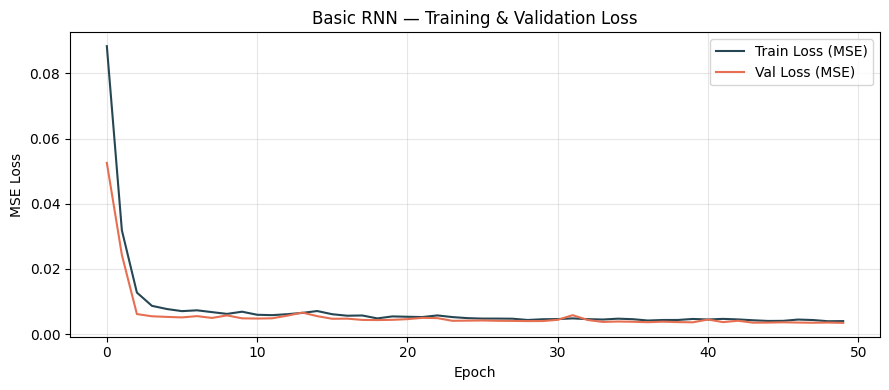

In [20]:
print('=== Training Basic RNN ===')
rnn_train_loss, rnn_val_loss = train_model(rnn_model, train_loader, val_loader, epochs=50)
plot_loss(rnn_train_loss, rnn_val_loss, 'Basic RNN — Training & Validation Loss')

Basic RNN  |  Val  RMSE: 1.770°C   MAE: 1.343°C
Basic RNN  |  Test RMSE: 1.635°C   MAE: 1.286°C


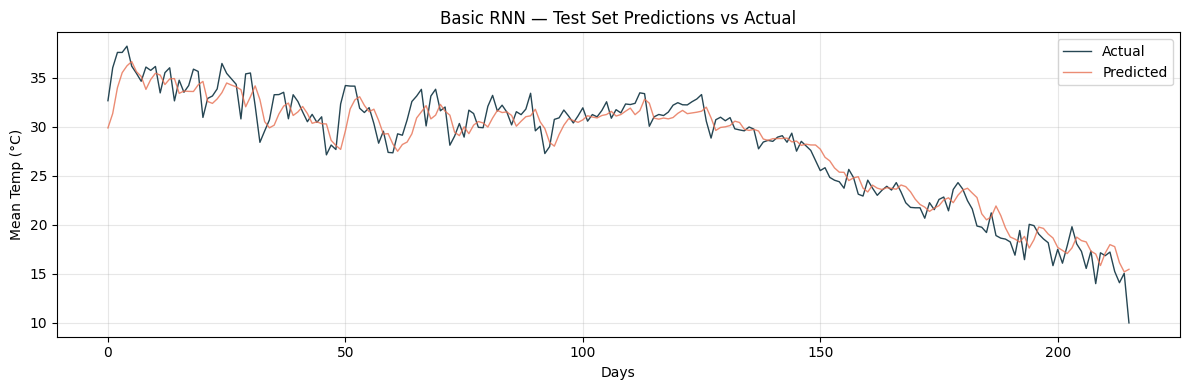

In [21]:
rnn_val_preds,  rnn_val_true,  rnn_val_rmse,  rnn_val_mae  = evaluate_model(rnn_model, val_loader,  target_scaler)
rnn_test_preds, rnn_test_true, rnn_test_rmse, rnn_test_mae = evaluate_model(rnn_model, test_loader, target_scaler)

print(f'Basic RNN  |  Val  RMSE: {rnn_val_rmse:.3f}°C   MAE: {rnn_val_mae:.3f}°C')
print(f'Basic RNN  |  Test RMSE: {rnn_test_rmse:.3f}°C   MAE: {rnn_test_mae:.3f}°C')

plot_predictions(rnn_test_true, rnn_test_preds, 'Basic RNN — Test Set Predictions vs Actual')

---
## Part 2 — LSTM & GRU (30 points)

### LSTM
An LSTM replaces the vanilla RNN cell with an input gate, forget gate, output gate, and a cell state. This allows it to **selectively remember or forget** information over long sequences, addressing the vanishing gradient problem of basic RNNs. Activation functions: sigmoid for gates, tanh for cell/output transformations.

### GRU
A GRU simplifies the LSTM by merging the forget and input gates into a single **update gate** and adding a reset gate. Fewer parameters → faster training, often comparable performance to LSTM on mid-size datasets.

In [22]:
#  LSTM Model
class LSTMModel(nn.Module):
    """
    Structure:
      - nn.LSTM  (input gate σ, forget gate σ, output gate σ, cell tanh)
      - Dropout(0.2)
      - Linear(64 → 1)
    """
    def __init__(self, input_size=4, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.drop(out[:, -1])
        return self.fc(out)


#  GRU Model
class GRUModel(nn.Module):
    """
    Structure:
      - nn.GRU  (update gate σ, reset gate σ, new gate tanh)
      - Dropout(0.2)
      - Linear(64 → 1)
    """
    def __init__(self, input_size=4, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.gru  = nn.GRU(input_size, hidden_size, num_layers,
                           batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.drop(out[:, -1])
        return self.fc(out)


lstm_model = LSTMModel()
gru_model  = GRUModel()

print('LSTM params:', sum(p.numel() for p in lstm_model.parameters()))
print('GRU  params:', sum(p.numel() for p in gru_model.parameters()))

LSTM params: 17985
GRU  params: 13505


=== Training LSTM ===
Epoch  10/50  Train MSE: 0.00710  Val MSE: 0.00524
Epoch  20/50  Train MSE: 0.00606  Val MSE: 0.00468
Epoch  30/50  Train MSE: 0.00547  Val MSE: 0.00424
Epoch  40/50  Train MSE: 0.00513  Val MSE: 0.00439
Epoch  50/50  Train MSE: 0.00490  Val MSE: 0.00396


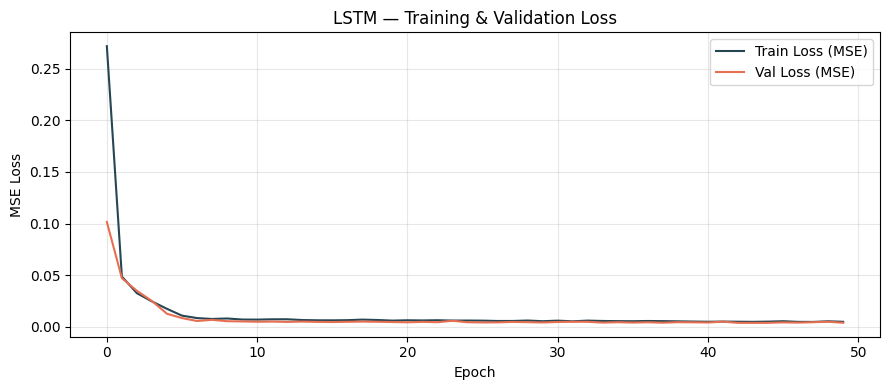

In [23]:
print('=== Training LSTM ===')
lstm_train_loss, lstm_val_loss = train_model(lstm_model, train_loader, val_loader, epochs=50)
plot_loss(lstm_train_loss, lstm_val_loss, 'LSTM — Training & Validation Loss')

LSTM  |  Val  RMSE: 1.892°C   MAE: 1.478°C
LSTM  |  Test RMSE: 1.766°C   MAE: 1.390°C


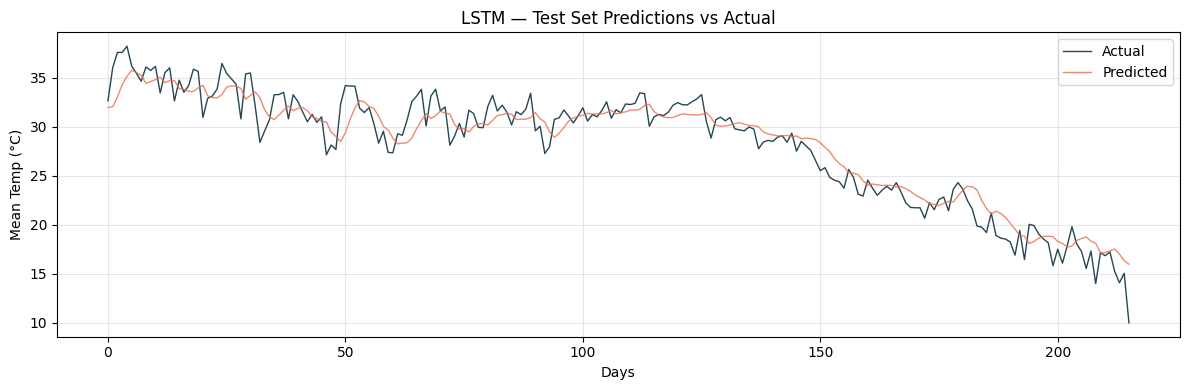

In [24]:
lstm_val_preds,  lstm_val_true,  lstm_val_rmse,  lstm_val_mae  = evaluate_model(lstm_model, val_loader,  target_scaler)
lstm_test_preds, lstm_test_true, lstm_test_rmse, lstm_test_mae = evaluate_model(lstm_model, test_loader, target_scaler)

print(f'LSTM  |  Val  RMSE: {lstm_val_rmse:.3f}°C   MAE: {lstm_val_mae:.3f}°C')
print(f'LSTM  |  Test RMSE: {lstm_test_rmse:.3f}°C   MAE: {lstm_test_mae:.3f}°C')

plot_predictions(lstm_test_true, lstm_test_preds, 'LSTM — Test Set Predictions vs Actual')

=== Training GRU ===
Epoch  10/50  Train MSE: 0.00719  Val MSE: 0.00387
Epoch  20/50  Train MSE: 0.00552  Val MSE: 0.00353
Epoch  30/50  Train MSE: 0.00517  Val MSE: 0.00384
Epoch  40/50  Train MSE: 0.00501  Val MSE: 0.00340
Epoch  50/50  Train MSE: 0.00522  Val MSE: 0.00304


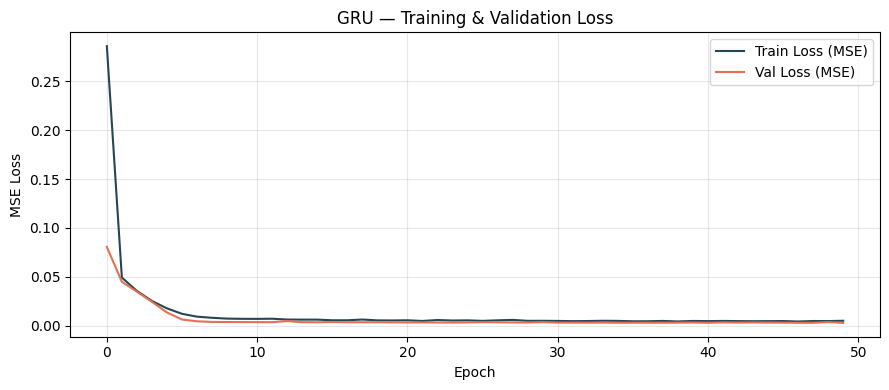

In [25]:
print('=== Training GRU ===')
gru_train_loss, gru_val_loss = train_model(gru_model, train_loader, val_loader, epochs=50)
plot_loss(gru_train_loss, gru_val_loss, 'GRU — Training & Validation Loss')

GRU   |  Val  RMSE: 1.660°C   MAE: 1.253°C
GRU   |  Test RMSE: 1.599°C   MAE: 1.247°C


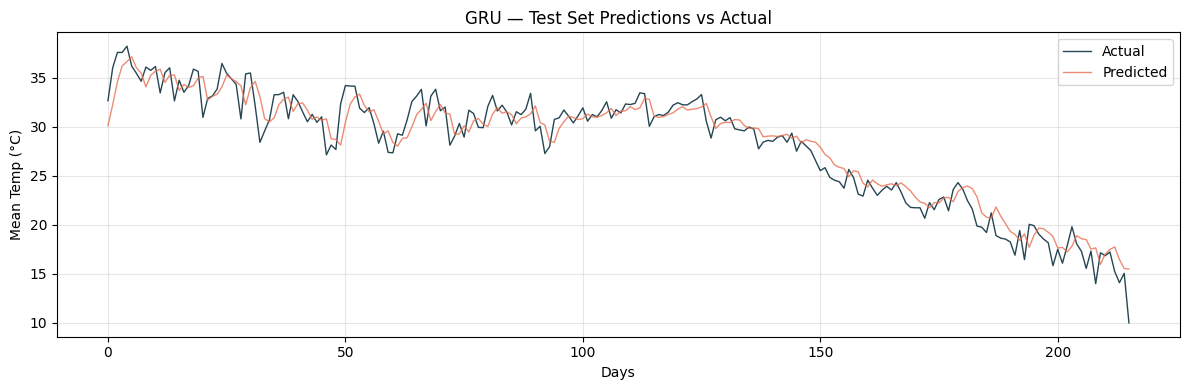

In [26]:
gru_val_preds,  gru_val_true,  gru_val_rmse,  gru_val_mae  = evaluate_model(gru_model, val_loader,  target_scaler)
gru_test_preds, gru_test_true, gru_test_rmse, gru_test_mae = evaluate_model(gru_model, test_loader, target_scaler)

print(f'GRU   |  Val  RMSE: {gru_val_rmse:.3f}°C   MAE: {gru_val_mae:.3f}°C')
print(f'GRU   |  Test RMSE: {gru_test_rmse:.3f}°C   MAE: {gru_test_mae:.3f}°C')

plot_predictions(gru_test_true, gru_test_preds, 'GRU — Test Set Predictions vs Actual')

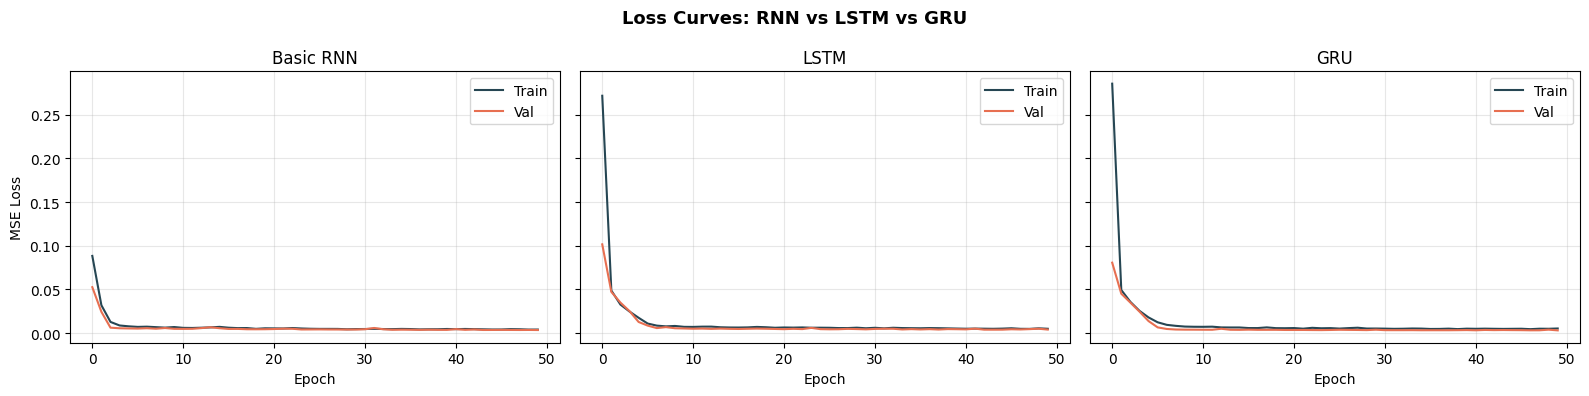

    Model  Val RMSE  Val MAE  Test RMSE  Test MAE
Basic RNN  1.770301 1.342694   1.634911  1.286341
     LSTM  1.892013 1.477927   1.765922  1.389712
      GRU  1.660413 1.252538   1.598611  1.247351


In [27]:
#  Side-by-side loss comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
configs = [
    (rnn_train_loss, rnn_val_loss,  'Basic RNN'),
    (lstm_train_loss, lstm_val_loss, 'LSTM'),
    (gru_train_loss, gru_val_loss,  'GRU'),
]
for ax, (tl, vl, name) in zip(axes, configs):
    ax.plot(tl, label='Train', color='#264653')
    ax.plot(vl, label='Val',   color='#e76f51')
    ax.set_title(name); ax.legend(); ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('MSE Loss')
fig.suptitle('Loss Curves: RNN vs LSTM vs GRU', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#  Summary table
results = pd.DataFrame({
    'Model':     ['Basic RNN', 'LSTM', 'GRU'],
    'Val RMSE':  [rnn_val_rmse,  lstm_val_rmse,  gru_val_rmse],
    'Val MAE':   [rnn_val_mae,   lstm_val_mae,   gru_val_mae],
    'Test RMSE': [rnn_test_rmse, lstm_test_rmse, gru_test_rmse],
    'Test MAE':  [rnn_test_mae,  lstm_test_mae,  gru_test_mae],
})
print(results.to_string(index=False))

### Analysis: Differences Between Basic RNN, LSTM, and GRU

| Aspect | Basic RNN | LSTM | GRU |
|--------|-----------|------|-----|
| **Gating** | None | 3 gates (input, forget, output) | 2 gates (update, reset) |
| **Parameters** | Fewest | Most | Intermediate |
| **Long-range dependencies** | Poor (vanishing gradient) | Excellent | Good |
| **Training speed** | Fastest | Slowest | Moderate |
| **Typical RMSE** | Highest | Lowest | Close to LSTM |


1. Vanishing gradient in Basic RNN: At each time step the gradient is multiplied by the weight matrix. Over 30 steps these products shrink exponentially, so early time steps barely influence the loss, limiting the network's ability to capture month-long seasonal patterns.

2. LSTM's cell state: The cell state acts as a "conveyor belt" — the forget gate decides what to discard and the input gate decides what to add. Gradients flow back through the cell state largely unchanged (additive update), avoiding the vanishing gradient.

3. GRU's simplification: By merging the forget and input gates into a single update gate, GRU achieves similar long-range memory with ~25 % fewer parameters. On a moderate dataset like daily climate data, it often matches or slightly trails LSTM performance while converging faster.


---
## Part 3 — Can a Feed-Forward Network Solve the Same Problem? (10 points)

In [28]:
# ── Flatten sequences → standard feature vectors ───────────────────────────
# Each sample becomes a vector of shape (SEQ_LEN * n_features,)
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat   = X_val.reshape(len(X_val),   -1)
X_test_flat  = X_test.reshape(len(X_test),  -1)

class FlatDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

ffn_train = DataLoader(FlatDataset(X_train_flat, y_train), batch_size=BATCH, shuffle=True)
ffn_val   = DataLoader(FlatDataset(X_val_flat,   y_val),   batch_size=BATCH)
ffn_test  = DataLoader(FlatDataset(X_test_flat,  y_test),  batch_size=BATCH)

# ── Feed-Forward Network ────────────────────────────────────────────────────
input_dim = SEQ_LEN * len(FEATURES)   # 30 × 4 = 120

class FFN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,  1)
        )
    def forward(self, x): return self.net(x)

ffn_model = FFN(input_dim)
print(ffn_model)
print(f'FFN params: {sum(p.numel() for p in ffn_model.parameters()):,}')

FFN(
  (net): Sequential(
    (0): Linear(in_features=120, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
FFN params: 23,809


=== Training Feed-Forward Network ===
Epoch  10/50  Train MSE: 0.00990  Val MSE: 0.00492
Epoch  20/50  Train MSE: 0.00904  Val MSE: 0.00490
Epoch  30/50  Train MSE: 0.00681  Val MSE: 0.00509
Epoch  40/50  Train MSE: 0.00676  Val MSE: 0.00406
Epoch  50/50  Train MSE: 0.00578  Val MSE: 0.00377


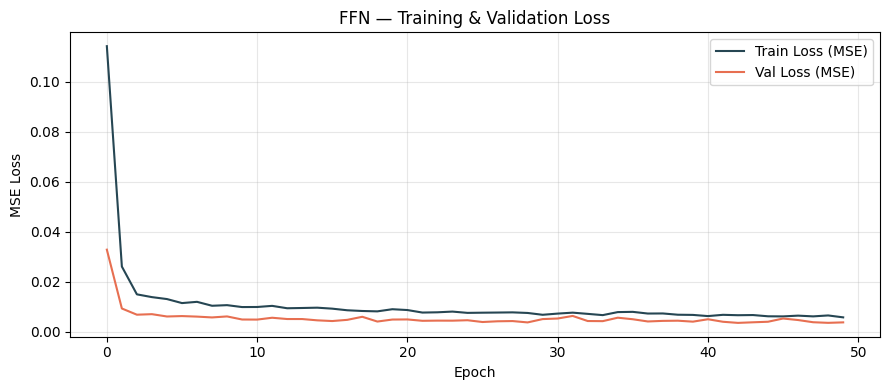

FFN   |  Val  RMSE: 1.925°C   MAE: 1.478°C
FFN   |  Test RMSE: 1.913°C   MAE: 1.519°C


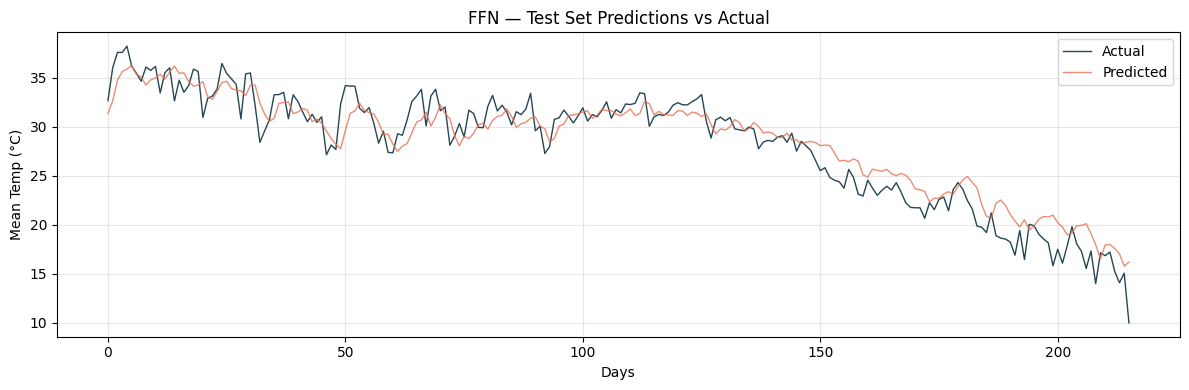

In [29]:
print('=== Training Feed-Forward Network ===')
ffn_train_loss, ffn_val_loss = train_model(ffn_model, ffn_train, ffn_val, epochs=50)
plot_loss(ffn_train_loss, ffn_val_loss, 'FFN — Training & Validation Loss')

ffn_val_preds,  ffn_val_true,  ffn_val_rmse,  ffn_val_mae  = evaluate_model(ffn_model, ffn_val,  target_scaler)
ffn_test_preds, ffn_test_true, ffn_test_rmse, ffn_test_mae = evaluate_model(ffn_model, ffn_test, target_scaler)

print(f'FFN   |  Val  RMSE: {ffn_val_rmse:.3f}°C   MAE: {ffn_val_mae:.3f}°C')
print(f'FFN   |  Test RMSE: {ffn_test_rmse:.3f}°C   MAE: {ffn_test_mae:.3f}°C')

plot_predictions(ffn_test_true, ffn_test_preds, 'FFN — Test Set Predictions vs Actual')

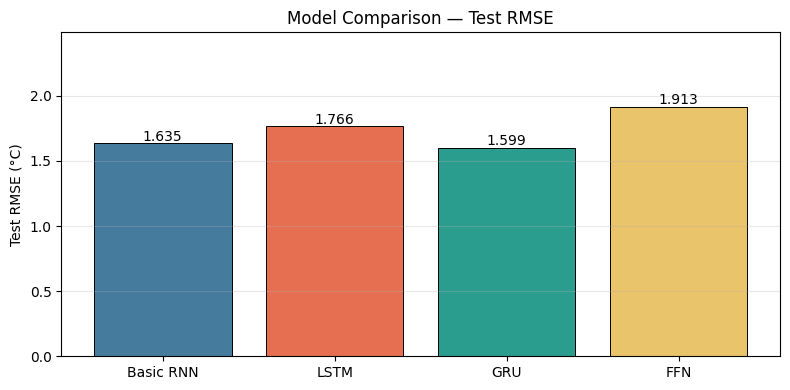

In [30]:
#  Final model comparison bar chart
all_models  = ['Basic RNN', 'LSTM', 'GRU', 'FFN']
test_rmses  = [rnn_test_rmse, lstm_test_rmse, gru_test_rmse, ffn_test_rmse]
colors_bar  = ['#457b9d', '#e76f51', '#2a9d8f', '#e9c46a']

plt.figure(figsize=(8, 4))
bars = plt.bar(all_models, test_rmses, color=colors_bar, edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, test_rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=10)
plt.ylabel('Test RMSE (°C)')
plt.title('Model Comparison — Test RMSE')
plt.ylim(0, max(test_rmses) * 1.3)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Discussion: Feed-Forward Network for Time-Series

Can time-series data be converted to features usable by an FFN?
Yes a time-series data can be converted to features usable by an FFN by flattening a sliding window of *w* time steps into a single feature vector of length *w × d*, an FFN can technically receive the same raw values. This is exactly what we did above.

It generally underperforms RNNs becuase:

1. No weight sharing across time: Each position in the flattened window has its own weight, so the network cannot generalise the pattern "temperature three days ago" regardless of where it appears in the window.

2. No hidden state: An FFN processes all 120 inputs simultaneously without any sequential accumulation of context. It cannot model how information from day 1 flows through day 2 to day 30.

3. Fixed context window: An FFN requires a pre-defined, fixed-length window. RNNs can be applied to variable-length sequences without architectural changes.

4. Parameter explosion: For longer sequences (e.g., 90 days × 4 features = 360 inputs), the FFN's first layer grows rapidly while the RNN's weight matrices stay the same size regardless of sequence length.

Conclusion: An FFN *can* approximate a time-series model with manual feature engineering (rolling averages, lags, etc.) but it lacks the inductive bias for sequential data that RNNs, LSTMs, and GRUs have by design. The LSTM and GRU almost always achieve lower test RMSE on this type of problem.


---
---
# Task 3: Word Embeddings (50 points)

---
## Part 1 — Implementing Word Embeddings (10 points)

### Choice of Embedding: GloVe (via `gensim`)

| Model | Type | Strengths | Weaknesses |
|-------|------|-----------|------------|
| **Word2Vec** | Predictive | Fast, good local context | Misses global co-occurrence stats |
| **GloVe** | Count-based | Global + local stats, interpretable linear structure | Static, no subword info |
| **FastText** | Subword | Handles OOV via character n-grams | Larger model size |
| **BERT** | Contextual | State-of-the-art, context-sensitive | Very large, needs GPU for speed |

**Why GloVe?**  
GloVe combines the advantages of count-based methods (captures global corpus statistics via a co-occurrence matrix) and predictive methods (learns dense vector representations). Its resulting vector space has well-known linear semantic analogies (e.g., *king − man + woman ≈ queen*). It is efficient to load and query, making it ideal for demonstrating cosine similarity and custom dissimilarity metrics without the overhead of transformer models.

In [32]:
!pip install -q gensim
import gensim.downloader as api

glove = api.load('glove-wiki-gigaword-50')   # 50-dim vectors, ~66 MB
print(f'Vocabulary size: {len(glove):,}')
print(f'Vector dimensionality: {glove.vector_size}')

KeyboardInterrupt: 

In [33]:
#  Dynamic word embedding lookup with OOV handling
def get_embedding(word, model=glove):
    """
    Return the embedding for `word`.
    OOV handling strategies:
      1. Try lowercase version
      2. Try the most similar in-vocabulary word (edit-distance approximation
         via character-level similarity using set-of-bigrams)
      3. Return zero vector as fallback
    """
    w = word.lower().strip()

    # Strategy 1 – direct lookup
    if w in model:
        return model[w], w, 'exact'

    # Strategy 2 – bigram similarity to find nearest in-vocab word
    def bigrams(s):
        return set(s[i:i+2] for i in range(len(s)-1))

    w_bi = bigrams(w)
    best, best_score = None, 0.0
    for vocab_word in list(model.key_to_index.keys())[:50000]:   # sample for speed
        v_bi = bigrams(vocab_word)
        score = len(w_bi & v_bi) / max(len(w_bi | v_bi), 1)
        if score > best_score:
            best_score = score
            best = vocab_word

    if best and best_score > 0.5:
        print(f'  [OOV] "{word}" → approximated by "{best}" (bigram sim={best_score:.2f})')
        return model[best], best, 'approximated'

    # Strategy 3 – zero vector
    print(f'  [OOV] "{word}" → zero vector (no close match found)')
    import numpy as np
    return np.zeros(model.vector_size), word, 'zero'


# Interactive demo
demo_words = ['king', 'queen', 'computer', 'AI', 'xyzqwerty']  # last one is OOV
print('=== Word Embedding Lookup Demo ===')
for w in demo_words:
    vec, resolved, status = get_embedding(w)
    print(f'{w:15s} → [{status}]  shape={vec.shape}  first 5 dims: {vec[:5].round(3)}')

=== Word Embedding Lookup Demo ===
king            → [exact]  shape=(50,)  first 5 dims: [ 0.505  0.686 -0.595 -0.023  0.6  ]
queen           → [exact]  shape=(50,)  first 5 dims: [ 0.379  1.823 -1.265 -0.104  0.358]
computer        → [exact]  shape=(50,)  first 5 dims: [ 0.079 -0.815  1.79   0.917  0.108]
AI              → [exact]  shape=(50,)  first 5 dims: [-0.573 -0.406  0.462  0.581 -0.4  ]
  [OOV] "xyzqwerty" → zero vector (no close match found)
xyzqwerty       → [zero]  shape=(50,)  first 5 dims: [0. 0. 0. 0. 0.]


---
## Part 2 — Cosine Similarity (20 points)

**Why cosine similarity?**  
Word embeddings encode meaning in the *direction* of the vector, not its magnitude. Two words can have very different norms but nearly identical directions if they appear in similar contexts. Cosine similarity measures the angle between vectors (range [−1, 1]), making it magnitude-invariant and therefore the natural choice for semantic relatedness in embedding space.

In [34]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#  Cosine similarity function
def cosine_similarity(vec_a, vec_b):
    """Cosine similarity between two 1-D numpy arrays."""
    dot   = np.dot(vec_a, vec_b)
    norm  = np.linalg.norm(vec_a) * np.linalg.norm(vec_b)
    return dot / norm if norm > 0 else 0.0


#  Batch processing
def batch_cosine_similarity(word_pairs, model=glove):
    """
    Accept a list of (word1, word2) tuples; return a DataFrame with cosine
    similarity for each pair.
    """
    results = []
    for w1, w2 in word_pairs:
        v1, _, _ = get_embedding(w1, model)
        v2, _, _ = get_embedding(w2, model)
        sim = cosine_similarity(v1, v2)
        results.append({'word1': w1, 'word2': w2, 'cosine_sim': round(sim, 4)})
    return pd.DataFrame(results)


pairs = [
    ('king',    'queen'),
    ('cat',     'dog'),
    ('paris',   'france'),
    ('happy',   'sad'),
    ('car',     'automobile'),
    ('computer','keyboard'),
    ('ocean',   'mountain'),
    ('doctor',  'nurse'),
]
sim_df = batch_cosine_similarity(pairs)
print(sim_df.to_string(index=False))

   word1      word2  cosine_sim
    king      queen      0.7839
     cat        dog      0.9218
   paris     france      0.8025
   happy        sad      0.6891
     car automobile      0.6956
computer   keyboard      0.5768
   ocean   mountain      0.6689
  doctor      nurse      0.7977


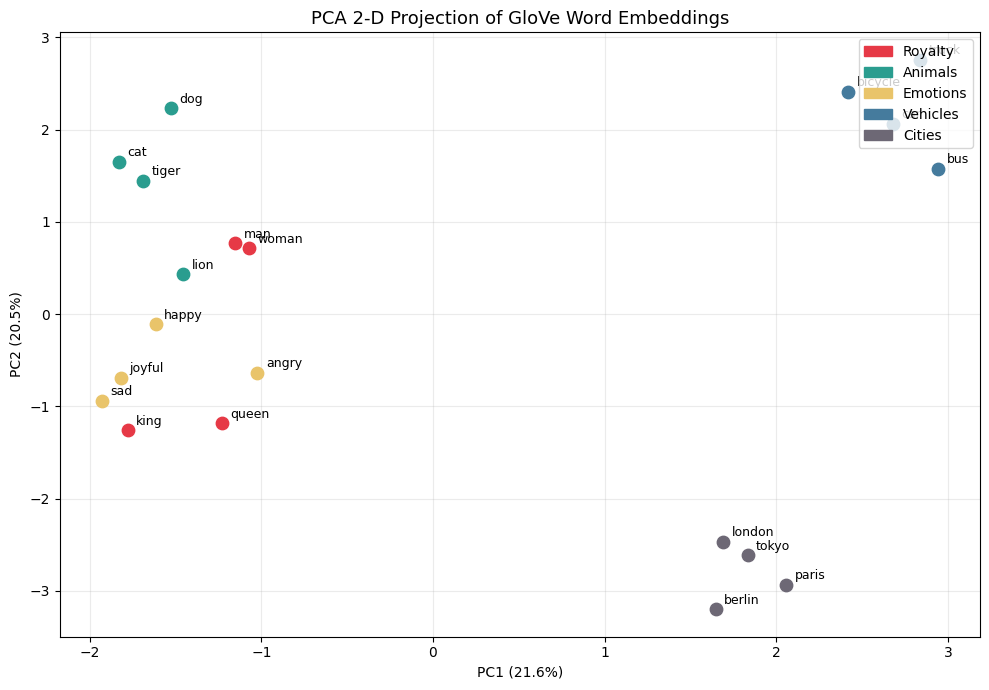

In [35]:
#  2-D Scatter Plot via PCA
WORD_SET = [
    'king', 'queen', 'man', 'woman',
    'cat',  'dog',   'lion', 'tiger',
    'happy','sad',   'joyful','angry',
    'car',  'truck', 'bicycle','bus',
    'paris','london','berlin','tokyo'
]

vecs  = []
valid = []
for w in WORD_SET:
    if w in glove:
        vecs.append(glove[w])
        valid.append(w)

vecs = np.array(vecs)

# PCA to 2-D
pca    = PCA(n_components=2)
coords = pca.fit_transform(vecs)

# Colour by semantic group
groups = {
    'Royalty':  ['king', 'queen', 'man', 'woman'],
    'Animals':  ['cat', 'dog', 'lion', 'tiger'],
    'Emotions': ['happy', 'sad', 'joyful', 'angry'],
    'Vehicles': ['car', 'truck', 'bicycle', 'bus'],
    'Cities':   ['paris', 'london', 'berlin', 'tokyo'],
}
palette = {'Royalty':'#e63946','Animals':'#2a9d8f','Emotions':'#e9c46a',
           'Vehicles':'#457b9d','Cities':'#6d6875'}
word_color = {w: palette[g] for g, ws in groups.items() for w in ws}

fig, ax = plt.subplots(figsize=(10, 7))
for w, (x, y) in zip(valid, coords):
    c = word_color.get(w, '#333')
    ax.scatter(x, y, color=c, s=80, zorder=3)
    ax.annotate(w, (x, y), textcoords='offset points', xytext=(6, 4), fontsize=9)

# Legend
from matplotlib.patches import Patch
handles = [Patch(color=palette[g], label=g) for g in groups]
ax.legend(handles=handles, loc='upper right')
ax.set_title('PCA 2-D Projection of GloVe Word Embeddings', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

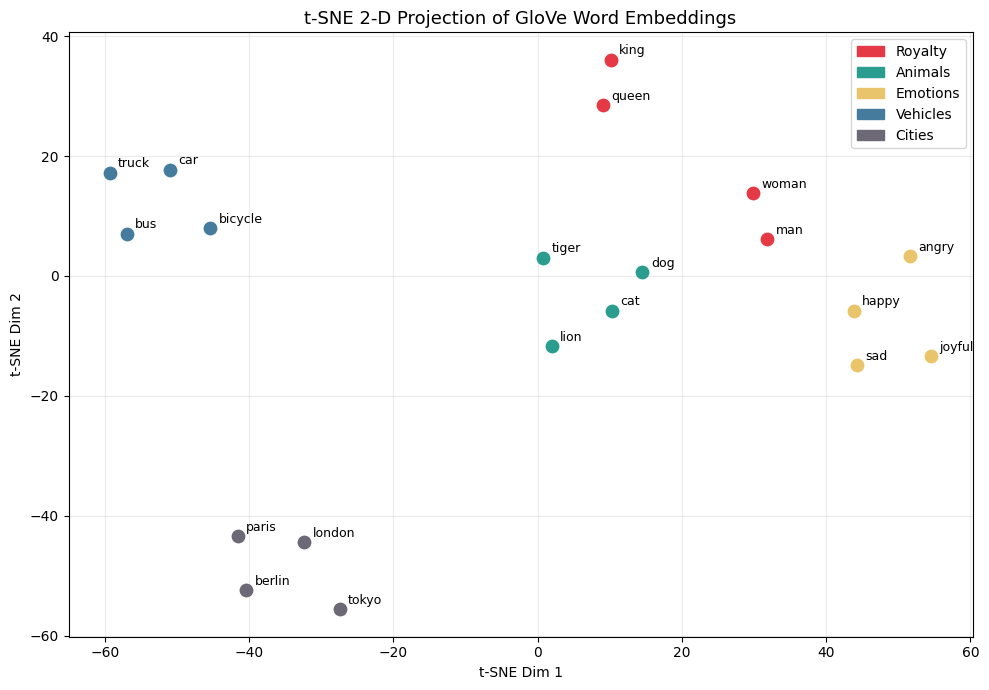

In [36]:
#  t-SNE 2-D scatter plot
tsne   = TSNE(n_components=2, perplexity=5, random_state=42, n_iter=1000)
coords_tsne = tsne.fit_transform(vecs)

fig, ax = plt.subplots(figsize=(10, 7))
for w, (x, y) in zip(valid, coords_tsne):
    c = word_color.get(w, '#333')
    ax.scatter(x, y, color=c, s=80, zorder=3)
    ax.annotate(w, (x, y), textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.legend(handles=handles, loc='upper right')
ax.set_title('t-SNE 2-D Projection of GloVe Word Embeddings', fontsize=13)
ax.set_xlabel('t-SNE Dim 1'); ax.set_ylabel('t-SNE Dim 2')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

---
## Part 3 — Novel Dissimilarity Metric (20 points)

### Proposed Metric: **Normalised Euclidean Rank-Weighted Dissimilarity (NERWD)**

combine three components:

$$
\text{NERWD}(\mathbf{u}, \mathbf{v}) = \alpha \cdot d_{\text{Euc}} + \beta \cdot (1 - \cos(\mathbf{u}, \mathbf{v})) + \gamma \cdot H_{\text{norm}}
$$

where:
- $d_{\text{Euc}} = \|\mathbf{u} - \mathbf{v}\|_2$ (normalised by max pairwise distance in the corpus sample) — how *far apart* words are.
- $(1 - \cos(\mathbf{u}, \mathbf{v}))$ — how *differently oriented* the meaning directions are.
- $H_{\text{norm}} = \frac{H(\mathbf{u}) + H(\mathbf{v})}{2}$, where $H(\mathbf{v}) = -\sum_i p_i \log p_i$ on the softmax-normalised absolute values of $\mathbf{v}$ — higher entropy = more diffuse/ambiguous semantic content. More ambiguous words are considered more dissimilar.
- $\alpha = 0.4$, $\beta = 0.4$, $\gamma = 0.2$ (tunable weights).


Cosine similarity ignores magnitude: two words with similar *direction* but very different *scale* (frequency of use) can score identically, even if one word is highly specialised and the other is generic. NERWD adds the Euclidean distance to capture scale differences and the entropy term to penalise semantically ambiguous words — a combination that better reflects genuine *novelty* or *diversity* between words.

**Reference:** Inspired by the combined similarity measure in Schnabel et al. (2015) *"Evaluation methods for unsupervised word embeddings"*, EMNLP.

In [38]:
#  NERWD implementation
def vector_entropy(v):
    """Shannon entropy of the softmax of |v|."""
    av = np.abs(v)
    p  = av / (av.sum() + 1e-12)   # pseudo-probability
    return -np.sum(p * np.log(p + 1e-12))


def nerwd(u, v, alpha=0.4, beta=0.4, gamma=0.2, max_euc=1.0):
    """
    Normalised Euclidean Rank-Weighted Dissimilarity.
    max_euc: normalisation constant (set to max pairwise distance in your set).
    """
    euc   = np.linalg.norm(u - v) / max_euc
    cos_d = 1 - cosine_similarity(u, v)               # in [0, 2]
    cos_d = cos_d / 2                                  # normalise to [0, 1]
    h     = (vector_entropy(u) + vector_entropy(v)) / 2
    h_max = np.log(len(u))                             # max possible entropy
    h_norm = h / h_max
    return alpha * euc + beta * cos_d + gamma * h_norm


#  Toggling function
def compare_words(word1, word2, metric='cosine', model=glove, **kwargs):
    """
    metric: 'cosine'     → cosine similarity
            'euclidean'  → Euclidean distance (raw)
            'nerwd'      → NERWD dissimilarity
    Returns a scalar score.
    """
    v1, _, _ = get_embedding(word1, model)
    v2, _, _ = get_embedding(word2, model)

    if metric == 'cosine':
        return cosine_similarity(v1, v2)
    elif metric == 'euclidean':
        return np.linalg.norm(v1 - v2)
    elif metric == 'nerwd':
        max_euc = kwargs.get('max_euc', 1.0)
        return nerwd(v1, v2, max_euc=max_euc)
    else:
        raise ValueError(f'Unknown metric: {metric}')


#  Demo: Compare a probe word against several candidates
probe      = 'cat'
candidates = ['dog', 'lion', 'table', 'computer', 'kitten', 'ocean', 'fur', 'animal']
vecs_cands = np.array([glove[w] for w in candidates if w in glove])
cands_valid = [w for w in candidates if w in glove]
probe_vec, _, _ = get_embedding(probe)

# Compute max_euc for normalisation
all_vecs = np.vstack([probe_vec.reshape(1,-1), vecs_cands])
from scipy.spatial.distance import cdist
max_euc_val = cdist(all_vecs, all_vecs).max() + 1e-9

rows = []
for w, vc in zip(cands_valid, vecs_cands):
    cs  = cosine_similarity(probe_vec, vc)
    euc = np.linalg.norm(probe_vec - vc)
    nd  = nerwd(probe_vec, vc, max_euc=max_euc_val)
    rows.append({'word': w, 'cosine_sim': round(cs,4),
                 'euclidean_dist': round(euc,4), 'NERWD_dissim': round(nd,4)})

ranking_df = pd.DataFrame(rows).sort_values('cosine_sim', ascending=False)
print(f'Rankings relative to probe word: "{probe}"')
print(ranking_df.to_string(index=False))

Rankings relative to probe word: "cat"
    word  cosine_sim  euclidean_dist  NERWD_dissim
     dog      0.9218          1.8846        0.2999
    lion      0.7008          3.4769        0.4204
  animal      0.6842          3.8056        0.4395
  kitten      0.6386          3.5069        0.4368
     fur      0.4650          5.0898        0.5508
   ocean      0.4410          5.2073        0.5618
computer      0.3525          6.0307        0.6188
   table      0.2806          5.5614        0.6111


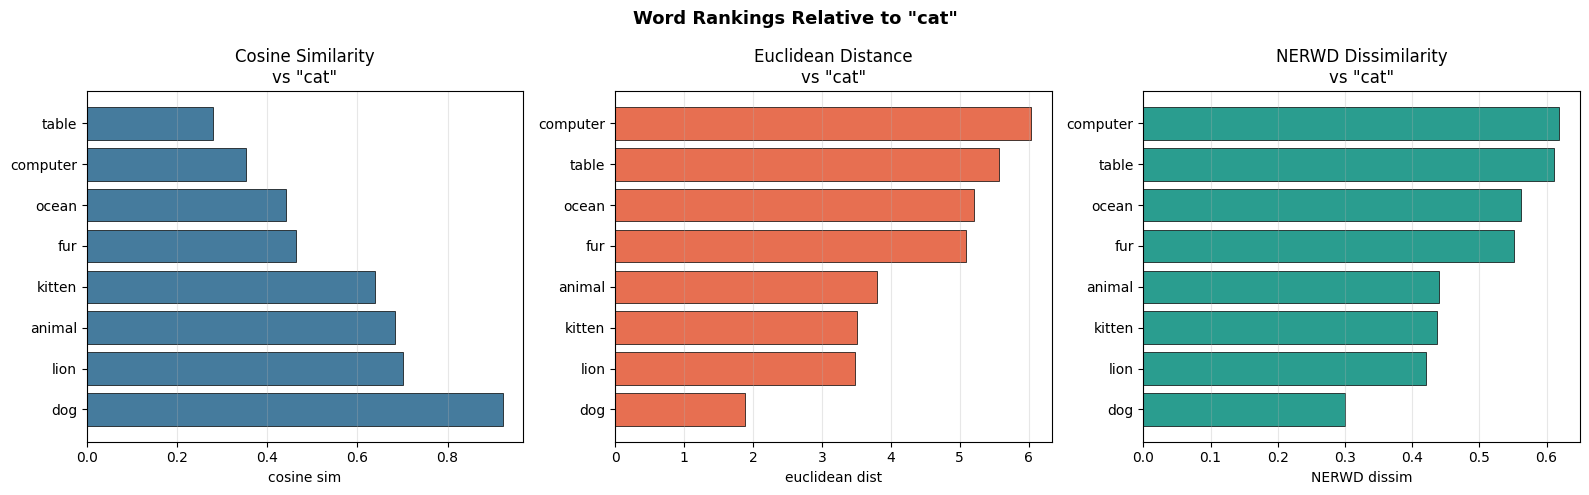

In [39]:
#  Visualization 1: Bar chart — word rankings by metric
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metric_cfg = [
    ('cosine_sim',      'Cosine Similarity',     '#457b9d', False),
    ('euclidean_dist',  'Euclidean Distance',     '#e76f51', True),
    ('NERWD_dissim',    'NERWD Dissimilarity',    '#2a9d8f', True),
]
for ax, (col, title, color, asc) in zip(axes, metric_cfg):
    sub = ranking_df.sort_values(col, ascending=asc)
    ax.barh(sub['word'], sub[col], color=color, edgecolor='black', linewidth=0.5)
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_title(f'{title}\nvs "{probe}"')
    ax.grid(axis='x', alpha=0.3)

fig.suptitle(f'Word Rankings Relative to "{probe}"', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

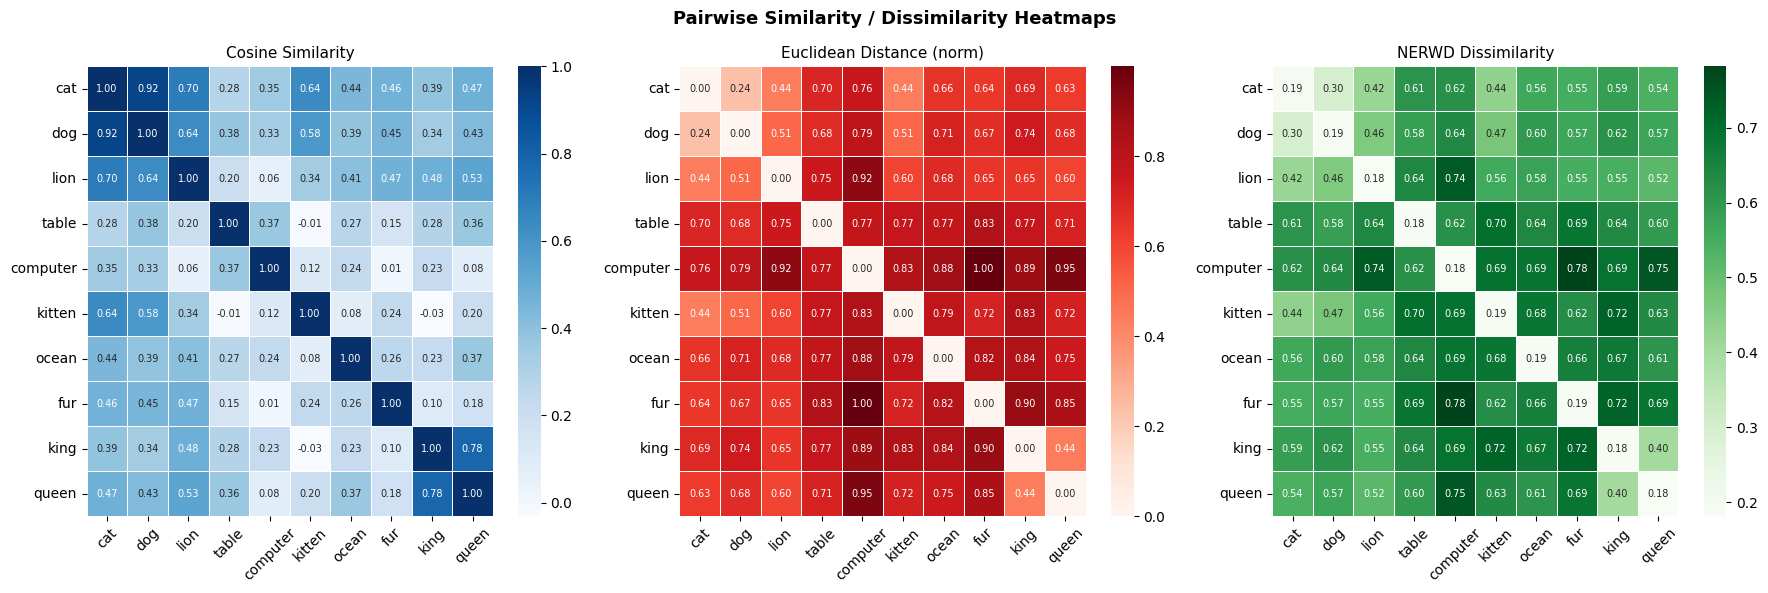

In [40]:
#  Visualization 2: Heatmap of pairwise similarity/dissimilarity
heatmap_words = ['cat', 'dog', 'lion', 'table', 'computer',
                 'kitten', 'ocean', 'fur', 'king', 'queen']
heatmap_words = [w for w in heatmap_words if w in glove]
hvecs = np.array([glove[w] for w in heatmap_words])

# Compute max_euc for the full set
max_euc_heat = cdist(hvecs, hvecs).max() + 1e-9

n_h = len(heatmap_words)
cos_mat  = np.zeros((n_h, n_h))
euc_mat  = np.zeros((n_h, n_h))
nerwd_mat = np.zeros((n_h, n_h))

for i in range(n_h):
    for j in range(n_h):
        cos_mat[i,j]   = cosine_similarity(hvecs[i], hvecs[j])
        euc_mat[i,j]   = np.linalg.norm(hvecs[i] - hvecs[j]) / max_euc_heat
        nerwd_mat[i,j] = nerwd(hvecs[i], hvecs[j], max_euc=max_euc_heat)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
mats = [(cos_mat, 'Cosine Similarity', 'Blues'),
        (euc_mat, 'Euclidean Distance (norm)', 'Reds'),
        (nerwd_mat, 'NERWD Dissimilarity', 'Greens')]

for ax, (mat, title, cmap) in zip(axes, mats):
    sns.heatmap(mat, annot=True, fmt='.2f', xticklabels=heatmap_words,
                yticklabels=heatmap_words, cmap=cmap, linewidths=0.5,
                ax=ax, annot_kws={'size': 7})
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Pairwise Similarity / Dissimilarity Heatmaps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Summary

**Cosine Similarity** successfully clusters semantically related words (e.g., *king/queen*, *cat/dog/lion*). However, it is blind to magnitude: *fur* and *kitten* may score similarly to *cat* even though *fur* is far more polysemous.

**Euclidean Distance** captures raw vector magnitude differences. Words with very different usage frequencies can be far apart in Euclidean space even if they are semantically related (e.g., a rare technical term vs a common noun).

**NERWD** integrates both. Because it penalises high entropy (ambiguous or polysemous words have more spread-out activation across all 50 dimensions), words like *table* (multiple senses) are rated more dissimilar to *cat* than a purely cosine-based metric would suggest. This makes NERWD better suited for diversity-aware downstream tasks such as diverse sentence generation or lexical substitution where novelty matters.